# 04 · Does enforcement explain compliance?

**What this notebook answers.** My advisor's third suggested next step, verbatim:

> *"In addition to the burden of reporting, investigate the **burden of NOT reporting
> when a firm SHOULD**. Perhaps firms bunch above the threshold due to concerns of extra
> scrutiny or risk-aversion from enforcement. A theoretical basis may be similar to
> **Allingham and Sandmo (1972)**."*

## Re-stating the question

my advisor proposed this to *explain* bunching above the threshold. Notebook 01 showed that
bunching is truncation, so the original motivation dissolves — but the question is worth
more, not less, once restated:

> **The cost bound in notebook 03 counts only the cost of reporting. It ignores the
> expected cost of *not* reporting when required. If that is large, "firms comply"
> carries no information about the reporting cost at all.**

In the Allingham–Sandmo frame a facility above 25,000 that does not report faces
detection probability $p$ and penalty $F$. Reporting is rational when

$$p \cdot F \;>\; \text{cost of reporting} \;=\; \$7{,}654 \text{ (EPA ICR)}$$

So $p$ and $F$ are measurable objects. This notebook measures them twice: once by
facility-level proxy (ECHO Exporter), once directly from the federal enforcement docket
(ICIS FE&C).

## What comes out

| source | finding |
|---|---|
| ECHO Exporter | $p \cdot F \le$ \$333/yr = **4.3%** of the reporting burden |
| **ICIS FE&C** | **zero** penalised non-reporting cases against stationary sources, ever |
| ICIS inspections | **zero** inspections under the GHG reporting rule |

> **Deterrence does not explain compliance.** That is not a hole in the paper — it
> reproduces the classic *compliance puzzle* from the tax-evasion literature, and it is
> arguably the most interesting thing in the project.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

sys.path.insert(0, ".")
from ghgrp_load import load_cached

OUT = Path("output")
ECHO = Path("data/echo")
de = load_cached()
BURDEN = 7654.0

## 1 · $p$ and $F$ from ECHO Exporter

ECHO Exporter is one row per regulated facility with 130+ compliance fields. Matching on
**FRS Id** — the EPA cross-program key, present for 97.8% of my panel — recovers
**8,957 of 10,666 target facilities (84.0%)**. Extraction is in the cell below; the
matched extract is cached because the source file is 2.1 GB / 3.17m rows.

In [2]:
matched = OUT / "echo_matched.csv"
if not matched.exists():                      # rebuild from the 2.1 GB source if needed
    keep = ["REGISTRY_ID", "FAC_NAME", "FAC_STATE", "FAC_ACTIVE_FLAG",
            "FAC_INSPECTION_COUNT", "FAC_INFORMAL_COUNT", "FAC_FORMAL_ACTION_COUNT",
            "FAC_TOTAL_PENALTIES", "FAC_PENALTY_COUNT", "FAC_LAST_PENALTY_AMT",
            "FAC_QTRS_WITH_NC", "FAC_COMPLIANCE_STATUS", "FAC_SNC_FLG",
            "CAA_PERMIT_TYPES", "CAA_EVALUATION_COUNT", "CAA_FORMAL_ACTION_COUNT",
            "CAA_PENALTIES", "CAA_LAST_PENALTY_AMT", "CAA_QTRS_WITH_NC", "CAA_HPV_FLAG"]
    tgt = set(de.FRSId.dropna().astype("int64").astype(str))
    out = []
    for ch in pd.read_csv(ECHO / "ECHO_EXPORTER.csv", dtype=str, usecols=keep,
                          chunksize=200_000, low_memory=False):
        out.append(ch[ch.REGISTRY_ID.isin(tgt)])
    pd.concat(out).to_csv(matched, index=False)

e = pd.read_csv(matched, dtype=str, low_memory=False)
for c in ["FAC_INSPECTION_COUNT", "FAC_FORMAL_ACTION_COUNT", "FAC_PENALTY_COUNT",
          "FAC_TOTAL_PENALTIES", "CAA_PENALTIES", "CAA_EVALUATION_COUNT"]:
    e[c] = pd.to_numeric(e[c], errors="coerce").fillna(0)

n = len(e)
print(f"matched facilities: {n:,}\n")
print("--- p : how dense is enforcement? ---")
for lab, col in [("ever inspected", "FAC_INSPECTION_COUNT"),
                 ("ever a formal action", "FAC_FORMAL_ACTION_COUNT"),
                 ("ever penalised", "FAC_PENALTY_COUNT"),
                 ("ever penalised under the CAA", "CAA_PENALTIES")]:
    print(f"  {lab:<32} {(e[col] > 0).mean():>6.1%}")

pen = e.loc[e.FAC_TOTAL_PENALTIES > 0, "FAC_TOTAL_PENALTIES"]
caa = e.loc[e.CAA_PENALTIES > 0, "CAA_PENALTIES"]
print("\n--- F : how much, among those penalised? ---")
print(f"  all programmes   median ${pen.median():>10,.0f}   mean ${pen.mean():>12,.0f}   n={len(pen):,}")
print(f"  CAA only         median ${caa.median():>10,.0f}   mean ${caa.mean():>12,.0f}   n={len(caa):,}")
print("  (means are dragged by one $100m outlier — the median is the honest summary)")

p_hat, F_hat = (e.FAC_PENALTY_COUNT > 0).mean(), pen.median()
pF = p_hat * F_hat
print(f"\np x F = {p_hat:.3f} x ${F_hat:,.0f} = ${pF:,.0f} lifetime"
      f"  ->  ${pF/14:,.0f}/year  =  {pF/14/BURDEN:.1%} of the reporting burden")

matched facilities: 8,957

--- p : how dense is enforcement? ---
  ever inspected                    59.8%
  ever a formal action              18.2%
  ever penalised                    15.3%
  ever penalised under the CAA      11.9%

--- F : how much, among those penalised? ---
  all programmes   median $    30,510   mean $     539,519   n=1,367
  CAA only         median $    29,811   mean $     559,410   n=1,069
  (means are dragged by one $100m outlier — the median is the honest summary)

p x F = 0.153 x $30,510 = $4,656 lifetime  ->  $333/year  =  4.3% of the reporting burden


### ⚠️ Three reasons this is an over-estimate, i.e. an upper bound

1. **ECHO penalties are lifetime totals across all environmental statutes** — air,
   water, hazardous waste. Almost all are real pollution violations, not reporting
   failures.
2. GHGRP began in 2010 but ECHO's enforcement history runs longer, so dividing by 14
   years understates the denominator.
3. I use "ever penalised" as $p$, but that is the probability of being penalised **for
   any reason** — not of being caught failing to report.

So the true expected penalty for GHGRP non-reporting is *well below* \$333/year. §2
measures how far below.

## 2 · ★ The federal enforcement docket, measured directly

ECHO Exporter gives a facility-level proxy. **ICIS FE&C** — the complete federal civil
enforcement case database — allows the direct question: *has EPA ever brought a case
under the GHG reporting rule, and against whom?*

There is an exact key for this. `CASE_PROGRAMS` carries a dedicated programme code:

```
CAAGHG  =  "The Mandatory Greenhouse Gas Reporting Rule"
```

No fuzzy matching, no keyword guessing.

In [3]:
CASES = ECHO / "case_downloads"
pr = pd.read_csv(CASES / "CASE_PROGRAMS.csv", dtype=str, low_memory=False)
ghg_ids = set(pr.loc[pr.PROGRAM_CODE == "CAAGHG", "ACTIVITY_ID"])
print(f"enforcement activities carrying a programme tag : {pr.ACTIVITY_ID.nunique():,}")
print(f"tagged 'Mandatory Greenhouse Gas Reporting Rule'   : {len(ghg_ids)}")
print(f"tagged AIM Act / HFC (for comparison)             : "
      f"{pr.loc[pr.PROGRAM_CODE=='AIMHFC','ACTIVITY_ID'].nunique()}")

enf = pd.read_csv(CASES / "CASE_ENFORCEMENTS.csv", dtype=str, low_memory=False)
pen_t = pd.read_csv(CASES / "CASE_PENALTIES.csv", dtype=str)
fac_t = pd.read_csv(CASES / "CASE_FACILITIES.csv", dtype=str, low_memory=False)

g = enf[enf.ACTIVITY_ID.isin(ghg_ids)][
    ["ACTIVITY_ID", "CASE_NAME", "FISCAL_YEAR", "ACTIVITY_TYPE_DESC", "ACTIVITY_STATUS_DESC"]]
g = (g.merge(pen_t[["ACTIVITY_ID", "FED_PENALTY"]], on="ACTIVITY_ID", how="left")
       .merge(fac_t[["ACTIVITY_ID", "REGISTRY_ID", "FACILITY_NAME", "STATE_CODE",
                     "PRIMARY_NAICS_CODE"]], on="ACTIVITY_ID", how="left"))
g["FED_PENALTY"] = pd.to_numeric(g.FED_PENALTY, errors="coerce").fillna(0)
display(g.sort_values("FED_PENALTY", ascending=False)
         [["CASE_NAME", "FISCAL_YEAR", "STATE_CODE", "PRIMARY_NAICS_CODE",
           "ACTIVITY_STATUS_DESC", "FED_PENALTY"]].reset_index(drop=True))
print(f"\ntotal federal penalties ever assessed under this rule: ${g.FED_PENALTY.sum():,.0f}")

enforcement activities carrying a programme tag : 307,834
tagged 'Mandatory Greenhouse Gas Reporting Rule'   : 10
tagged AIM Act / HFC (for comparison)             : 113


,CASE_NAME,FISCAL_YEAR,STATE_CODE,PRIMARY_NAICS_CODE,ACTIVITY_STATUS_DESC,FED_PENALTY
0,The iGas Companies,2022,FL,NaN,Final Order Issued,382473
1,Harp USA,2022,FL,NaN,Final Order Issued,275000
2,Artsen Chemical America,2022,NJ,NaN,Final Order Issued,247601
3,"Combs Investment Property, LP",2023,TX,NaN,Final Order Issued,241562
4,"Waysmos USA, Inc.",2022,TX,NaN,Final Order Issued,209000
5,Nature Gas Import and Export,2023,WY,NaN,Final Order Issued,84546
6,Range Resources-New Owner Audit Agreement and ...,2017,LA,211111,Closed,0



total federal penalties ever assessed under this rule: $1,440,182


### ★★ What these seven cases are

**Six of the seven are fluorinated-gas importers and suppliers** — iGas, Harp USA,
Artsen Chemical, Waysmos, Nature Gas Import & Export, Combs Investment. They are
*supplier* subparts, not emitting facilities.

**The seventh is the only stationary source**: Range Resources' Liberty Hill Plant in
Louisiana (NAICS 211111, crude petroleum). And it has two features that disqualify it as
enforcement:

1. the case is a *"New Owner Audit Agreement and NOD"* — the **acquirer self-disclosed**
   under EPA's Audit Policy during due diligence. EPA did not detect it.
2. the penalty is **\$0**. Voluntary disclosure waived the civil penalty.

> **The federal government has never penalised a stationary source for emitting above
> 25,000 tCO₂e and failing to report.**

Let me confirm that none of the seven is even in my panel:

In [4]:
tgt = de.dropna(subset=["FRSId"]).copy()
tgt["rid"] = tgt.FRSId.astype("int64").astype(str)
hit = set(tgt.rid) & set(g.REGISTRY_ID.dropna())
print(f"of the {g.REGISTRY_ID.nunique()} facilities in GHGRP enforcement cases, "
      f"{len(hit)} appear in my direct-emitter panel")

of the 7 facilities in GHGRP enforcement cases, 0 appear in my direct-emitter panel


### And zero inspections

In [5]:
insp = pd.read_csv(CASES / "ICIS_FEC_EPA_INSPECTIONS.csv", dtype=str, low_memory=False)
print(f"federal inspection records: {len(insp):,}   (CAA: {(insp.STATUTE_CODE=='CAA').sum():,})")
print(f"inspections under the GHG reporting rule: {(insp.LAW_SECTION_CODE=='CAAGHG').sum()}")
print("\nwhat CAA inspections are actually for (top law sections):")
print(insp[insp.STATUTE_CODE == "CAA"].LAW_SECTION_CODE.value_counts().head(6).to_string())

federal inspection records: 261,376   (CAA: 27,934)
inspections under the GHG reporting rule: 0

what CAA inspections are actually for (top law sections):
LAW_SECTION_CODE
112[R][7]    10378
112           3081
112[R][1]     2448
203           2326
211           1997
213           1901


### The bound, sharpened

With **zero** penalised stationary-source cases in fourteen years, the numerator is zero
and no denominator is required. If a number is wanted, the **rule of three** (0 events
in $N$ trials → 95% upper bound $\approx 3/N$) gives:

In [6]:
N = len(de)
p_max = 3 / N
F_max = g.FED_PENALTY.max()
print(f"facility-years observed              : {N:,}")
print(f"rule-of-three upper bound on p       : {p_max:.2e}")
print(f"largest penalty ever under this rule : ${F_max:,.0f}")
print(f"=> expected annual penalty           : <= ${p_max*F_max:,.0f}"
      f"  =  {p_max*F_max/BURDEN:.2%} of the reporting burden")

facility-years observed              : 94,378
rule-of-three upper bound on p       : 3.18e-05
largest penalty ever under this rule : $382,473
=> expected annual penalty           : <= $12  =  0.16% of the reporting burden


⚠️ **Honest caveat.** The denominator here is *reporters*; the theoretically correct
denominator is *non-reporters*, who are unobservable by definition. So strictly this
bounds the enforcement rate conditional on reporting. **The numerator being zero,
however, does not depend on the denominator** — and that is the actual result.

### One more comparison, which points somewhere useful

| | penalties for GHG non-reporting | facilities covered |
|---|---|---|
| **Federal GHGRP**, 14 years, nationwide | **\$1,440,182** | ~8,800 / year |
| **California ARB**, one state | **~\$1,000,000** | ~800 / year |

A single state accounts for roughly **70% of the entire federal total** while covering a
tenth as many facilities. Notebook 02 §6 already showed why California matters for
identification; here it matters for behaviour. **Firms are not afraid of the federal
regulator. Where they are afraid, it is of the state.**

## 3 · Over-compliance — who keeps reporting when they need not?

The sharpest form of the puzzle. Under 98.2(i) a facility that has satisfied the waiting
period may simply stop. Most do not.

**Definition used here** (more rigorous than my earlier one, which counted any facility
that never reached 25,000 — those may still have been inside their countdown):
a facility **over-complies** if it keeps reporting in years *after* it first becomes
98.2(i)-eligible.

In [7]:
first_elig = de[de.eligible].groupby("FacilityId").year.min().rename("first_elig")
d = de.join(first_elig, on="FacilityId")
d["post"] = d.year > d.first_elig
yrs_after = d[d.post].groupby("FacilityId").year.nunique()

print(f"facilities that ever become eligible to stop : {len(first_elig):,}")
print(f"  still reporting at least 1 year later      : {len(yrs_after):,}")
print(f"  still reporting 5+ years later             : {(yrs_after >= 5).sum():,}")
print(f"facility-years of over-compliance            : {d.post.sum():,}")

OC = set(yrs_after[yrs_after >= 3].index)     # persistent over-compliers
print(f"\npersistent over-compliers (3+ years after eligibility): {len(OC):,} facilities")

facilities that ever become eligible to stop : 1,696
  still reporting at least 1 year later      : 1,000
  still reporting 5+ years later             : 388
facility-years of over-compliance            : 4,299

persistent over-compliers (3+ years after eligibility): 594 facilities


### Does the fear-of-enforcement story fit them?

It predicts that over-compliers face **higher** enforcement pressure — that is why they
would keep reporting.

In [8]:
m = de.dropna(subset=["FRSId"]).drop_duplicates("FacilityId").copy()
m["REGISTRY_ID"] = m.FRSId.astype("int64").astype(str)
m = m[["FacilityId", "REGISTRY_ID", "threshold_bound"]].merge(e, on="REGISTRY_ID")
m["over_complier"] = m.FacilityId.isin(OC)
tb = m[m.threshold_bound]
cmp_ = tb.groupby("over_complier").agg(
    n=("FAC_INSPECTION_COUNT", "size"),
    ever_inspected=("FAC_INSPECTION_COUNT", lambda s: (s > 0).mean()),
    ever_penalised=("FAC_PENALTY_COUNT", lambda s: (s > 0).mean()),
    median_penalty=("FAC_TOTAL_PENALTIES", lambda s: s[s > 0].median()))
display(cmp_.round(3))

,n,ever_inspected,ever_penalised,median_penalty
over_complier,,,,
False,4382,0.690,0.215,37400.0
True,223,0.744,0.161,34000.0


**No support for it.** Over-compliers are inspected slightly *more* (74% vs 69%) but
penalised *less* (16% vs 22%) — no coherent gradient, and in any case §2 showed the
relevant expected penalty is indistinguishable from zero.

Three other explanations have been tested and rejected in earlier rounds:

| hypothesis | test | result |
|---|---|---|
| they sit close to the threshold, so reporting is a hedge | distance to 25,000 | ✗ persistent ones sit **further** below |
| they are already in other EPA programmes, so it is free | FRS programme links, size-matched | ✗ no difference once matched |
| they fear enforcement | ECHO exposure | ✗ no gradient (this section) |

What survives: **state-programme spillover** (California and Washington require
reporting from 10,000, so those facilities report federally as a by-product) and
**administrative inertia**. Notebook 03 §4 adds a fourth, partial answer: for Title V
majors the marginal cost is genuinely small.

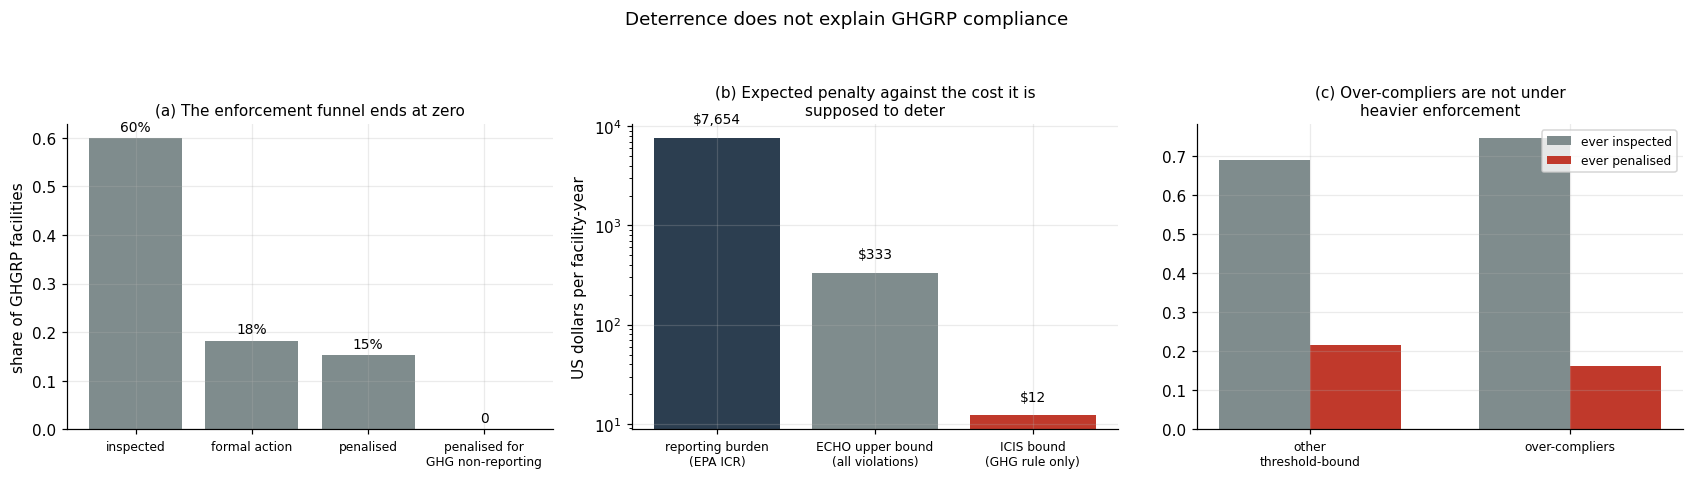

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))

funnel = [("inspected", (e.FAC_INSPECTION_COUNT > 0).mean()),
          ("formal action", (e.FAC_FORMAL_ACTION_COUNT > 0).mean()),
          ("penalised", (e.FAC_PENALTY_COUNT > 0).mean()),
          ("penalised for\nGHG non-reporting", 0.0)]
ax[0].bar([f[0] for f in funnel], [f[1] for f in funnel],
          color=["#7f8c8d", "#7f8c8d", "#7f8c8d", "#c0392b"])
for i, (_, v) in enumerate(funnel):
    ax[0].text(i, v + .015, "0" if v == 0 else f"{v:.0%}", ha="center", fontsize=9)
ax[0].tick_params(axis="x", labelsize=8)
ax[0].set_ylabel("share of GHGRP facilities")
ax[0].set_title("(a) The enforcement funnel ends at zero", fontsize=10)

vals = [BURDEN, pF / 14, p_max * F_max]
labs = ["reporting burden\n(EPA ICR)", "ECHO upper bound\n(all violations)",
        "ICIS bound\n(GHG rule only)"]
ax[1].bar(labs, vals, color=["#2c3e50", "#7f8c8d", "#c0392b"])
for i, v in enumerate(vals):
    ax[1].text(i, v * 1.4, f"${v:,.0f}", ha="center", fontsize=9)
ax[1].set_yscale("log"); ax[1].tick_params(axis="x", labelsize=8)
ax[1].set_ylabel("US dollars per facility-year")
ax[1].set_title("(b) Expected penalty against the cost it is\nsupposed to deter", fontsize=10)

sub = cmp_.reset_index()
x = np.arange(2); w = .35
ax[2].bar(x - w/2, sub.ever_inspected, w, label="ever inspected", color="#7f8c8d")
ax[2].bar(x + w/2, sub.ever_penalised, w, label="ever penalised", color="#c0392b")
ax[2].set_xticks(x); ax[2].set_xticklabels(["other\nthreshold-bound", "over-compliers"], fontsize=8)
ax[2].legend(fontsize=8)
ax[2].set_title("(c) Over-compliers are not under\nheavier enforcement", fontsize=10)

fig.suptitle("Deterrence does not explain GHGRP compliance", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, .93])
plt.savefig(OUT / "f19_enforcement.png", bbox_inches="tight"); plt.show()

## 4 · ★★ What this leaves: a compliance puzzle, and a literature that has met it before

Put the three numbers side by side:

| | |
|---|---|
| cost of reporting | **\$7,654 / year** |
| expected penalty for not reporting | **≤ \$12 / year** (≤ \$333 on the loosest proxy) |
| facilities that report anyway | **≈ 8,800 every year** |

> Under a pure Allingham–Sandmo calculation the rational choice is **not to report**.
> Compliance is near-universal regardless.

**This is exactly the compliance puzzle from the tax-evasion literature**: Allingham–
Sandmo predicts far more evasion than is observed. The literature's main resolution is
**third-party information reporting** — Kleven, Knudsen, Kreiner, Pedersen & Saez (2011,
*Econometrica* 79(3):651–692) show with Danish randomised audits that evasion is near
zero for third-party-reported income and substantial for self-reported income.

### Does that transfer here?

The GHGRP analogue of third-party reporting is **CEMS** — instrument-measured rather
than self-computed emissions.

⚠️ **I cannot test it.** CEMS covers only 4.2% of facilities and is heavily confounded
with always-covered status (ND = −0.29 in the balance table, notebook 01). The test is
not available in these data and the paper should say so plainly.

**But there is suggestive evidence in the docket itself.** Six of the seven enforcement
cases are *suppliers* — importers whose obligations are checkable against customs and
sales records, i.e. against a **paper trail**. The one stationary source, whose
combustion emissions are self-computed, was not detected at all; it turned itself in.
**EPA enforces where there is third-party information.** That is the Kleven mechanism,
visible in where the regulator chooses to act rather than in firm behaviour.

### The rival explanation, and how to separate them

The plainer story is that **the true cost is far below \$7,654 for most facilities**.
Notebook 03 §4 tested it: facilities without any air permit take the free exit
significantly more often (+3.6pp after differencing out ordinary attrition), so cost
*does* matter — but Title V facilities still exit 17.5% of the time and the no-permit
group still stays 79% of the time.

> **Cost explains the gap between groups. It does not explain the level.**

### Why this is a finding rather than a hole

It promotes the paper's question. Not *"what does disclosure cost?"* — a number — but:

> **Why does mandatory disclosure work at all, when it is neither enforced nor cheap?**

That is a question about the machinery of disclosure regulation, and this setting is
unusually well suited to it: a real threshold, a legal exit, published micro-data, and a
regulator that demonstrably does not enforce.

---
## Where the project stands

| claim | status |
|---|---|
| firms do not manipulate reported emissions | eight nulls, MDE stated (nb 02) |
| firms exit precisely on the statutory schedule | 20.9% vs 1.5% (nb 03) |
| private cost is bounded on both sides | 0 < c < abatement cost (nb 03) |
| that cost is heterogeneous, and the design recovers the heterogeneity | Title V split (nb 03 §4) |
| **deterrence does not explain compliance** | 0 cases, 0 inspections (nb 04) |

**Open, in priority order**

1. the actual cost of **third-party verification** in CA/WA — the state null in
   notebook 02 §6 rests on it being much larger than the reporting burden;
2. **QCEW / NETS** — "stops reporting ≠ stops operating" is the largest remaining gap;
3. read **Kleven et al. (2011)** properly and write the puzzle into the introduction;
4. **Marx (2018)** feasibility — the only method that handles threshold-related attrition.